# #7DaysOfCode - Ciência de Dados | Dia 1

## Limpeza e preparação dos dados

Neste primeiro dia do desafio, o objetivo é realizar a limpeza e o tratamento inicial dos dados das Cotas para Exercício da Atividade Parlamentar dos Senadores.

Serão verificadas possíveis inconsistências, como:

- Valores nulos;
- Registros duplicados;
- Tipos de dados incorretos;
- Campos de data carregados como texto;
- Valores monetários com formatação inadequada;
- Padronização de textos;
- Formatação de CNPJ;
- Outras inconsistências identificadas durante a análise exploratória.

Os dados utilizados neste projeto são referentes às Cotas para Exercício da Atividade Parlamentar dos Senadores, disponibilizados em formato aberto.

Para esta análise, foram utilizados os arquivos dos anos:

- 2024
- 2025
- 2026

Como os dados estão distribuídos em arquivos separados, a primeira etapa consiste em carregá-los e consolidá-los em uma única base para posterior tratamento e análise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Carregamento da base de dados

Nesta etapa, os dados são carregados para um DataFrame do pandas para permitir a análise e o tratamento das informações. 

In [4]:
# Carregando os arquivos de cada ano
df_2024 = pd.read_csv(
    "/content/drive/MyDrive/ceaps/despesas_ceaps_2024.csv",
    sep=';',
    encoding='latin1',
    on_bad_lines='skip'
)

df_2025 = pd.read_csv(
    "/content/drive/MyDrive/ceaps/despesas_ceaps_2025.csv",
    sep=';',
    encoding='latin1',
    on_bad_lines='skip'
) 

df_2026 = pd.read_csv(
    "/content/drive/MyDrive/ceaps/despesas_ceaps_2026.csv",
    sep=';',
    encoding='latin1',
    on_bad_lines='skip'
)

## Correção de caracteres com encoding inconsistente

Durante a análise dos dados, foi identificado que alguns campos textuais apresentavam caracteres corrompidos (ex: "LocomoÃ§Ã£o").

Esse problema ocorre devido à interpretação incorreta de encoding em etapas anteriores de processamento dos dados.

Para correção, foi aplicada uma estratégia de redecodificação manual dos textos, restaurando os caracteres originais.

In [5]:
%pip install ftfy
import ftfy

def corrigir_encoding(col):
    return col.apply(lambda x: ftfy.fix_text(x) if isinstance(x, str) else x)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 653.7 kB/s eta 0:00:000:00:01


In [6]:
for df_year in [df_2024, df_2025, df_2026]:
    for col in df_year.select_dtypes(include="object").columns:
        df_year[col] = corrigir_encoding(df_year[col])

INÍCIO DO TRATAMENTO DOS DADOS:



In [7]:
df_2024.shape
df_2025.shape
df_2026.shape 

(7197, 13)

In [8]:
df = pd.concat([df_2024, df_2025, df_2026], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52228 entries, 0 to 52227
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   52228 non-null  int64 
 1   TIPO_DOCUMENTO       52228 non-null  object
 2   ANO                  52228 non-null  int64 
 3   MÃS                 52228 non-null  int64 
 4   COD_SENADOR          52228 non-null  int64 
 5   NOME_SENADOR         52228 non-null  object
 6   TIPO_DESPESA         52017 non-null  object
 7   CPF_CNPJ_FORNECEDOR  52228 non-null  object
 8   NOME_FORNECEDOR      52228 non-null  object
 9   DOCUMENTO            49885 non-null  object
 10  DATA                 52228 non-null  object
 11  DETALHAMENTO         20260 non-null  object
 12  VALOR_REEMBOLSADO    52228 non-null  object
dtypes: int64(4), object(9)
memory usage: 5.2+ MB


In [9]:
# Padronização das colunas

df.columns = (
    df.columns.str.strip()  # Remove espaços em branco
    .str.upper()  # Converte para maiúsculas
    .str.replace(' ', '_')  # Substitui espaços por underscores
)

In [10]:
# Remoção de dados duplicados

duplicados = df.duplicated().sum()
print(f"Registros duplicados encontrados: {duplicados}")

df = df.drop_duplicates()

Registros duplicados encontrados: 0


In [11]:
# Tratamento de Nulos

nulos = df.isnull().sum().sort_values(ascending=False)
print("\nValores nulos por colunas:\n")
print(nulos)


Valores nulos por colunas:

DETALHAMENTO           31968
DOCUMENTO               2343
TIPO_DESPESA             211
TIPO_DOCUMENTO             0
ID                         0
COD_SENADOR                0
MÃS                       0
ANO                        0
NOME_SENADOR               0
NOME_FORNECEDOR            0
CPF_CNPJ_FORNECEDOR        0
DATA                       0
VALOR_REEMBOLSADO          0
dtype: int64


In [12]:
# CONVERSÃO DE TIPOS (SE NECESSÁRIO)

# Exemplo comum CEAPS: valores monetários
if 'VALOR_REEMBOLSADO' in df.columns:
    df['VALOR_REEMBOLSADO'] = (df['VALOR_REEMBOLSADO'].astype(str)
    .str.replace(".", " ", regex=False)
    .str.replace(",", ".", regex=False )
    )

    df["VALOR_REEMBOLSADO"] = pd.to_numeric(
        df["VALOR_REEMBOLSADO"],
        errors="coerce"    )

if 'VALOR_TOTAL' in df.columns:
    df['VALOR_TOTAL'] = (df['VALOR_TOTAL'].astype(str)
    .str.replace(".", " ", regex=False)
    .str.replace(",", ".", regex=False )
    )

    df["VALOR_TOTAL"] = pd.to_numeric(
        df["VALOR_TOTAL"],
        errors="coerce"    )
    
if 'VALOR_UNITARIO' in df.columns:
    df['VALOR_UNITARIO'] = (df['VALOR_UNITARIO'].astype(str)
    .str.replace(".", " ", regex=False)
    .str.replace(",", ".", regex=False )
    )

    df["VALOR_UNITARIO"] = pd.to_numeric(
        df["VALOR_UNITARIO"],
        errors="coerce"    )
    



In [13]:
#  VISÃO GERAL FINAL

print("\nINFO DO DATASET:")
print(df.info())

print("\nDESCRIÇÃO ESTATÍSTICA:")
display(df.describe(include="all"))


INFO DO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52228 entries, 0 to 52227
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   52228 non-null  int64  
 1   TIPO_DOCUMENTO       52228 non-null  object 
 2   ANO                  52228 non-null  int64  
 3   MÃS                 52228 non-null  int64  
 4   COD_SENADOR          52228 non-null  int64  
 5   NOME_SENADOR         52228 non-null  object 
 6   TIPO_DESPESA         52017 non-null  object 
 7   CPF_CNPJ_FORNECEDOR  52228 non-null  object 
 8   NOME_FORNECEDOR      52228 non-null  object 
 9   DOCUMENTO            49885 non-null  object 
 10  DATA                 52228 non-null  object 
 11  DETALHAMENTO         20260 non-null  object 
 12  VALOR_REEMBOLSADO    52228 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 5.2+ MB
None

DESCRIÇÃO ESTATÍSTICA:


,ID,TIPO_DOCUMENTO,ANO,MÃS,COD_SENADOR,NOME_SENADOR,TIPO_DESPESA,CPF_CNPJ_FORNECEDOR,NOME_FORNECEDOR,DOCUMENTO,DATA,DETALHAMENTO,VALOR_REEMBOLSADO
count,5.222800e+04,52228,52228.000000,52228.000000,52228.000000,52228,52017,52228,52228,49885,52228,20260,52228.000000
unique,NaN,7,NaN,NaN,NaN,97,7,6197,6654,40023,953,9731,NaN
top,NaN,Nota Fiscal Eletrônica,NaN,NaN,NaN,GIORDANO,"Locomoção, hospedagem, alimentação, combustíve...",05.120.923/0001-09,Aerotur Serviços,s/n,2025-09-01,DESPESA COM COMBUSTÍVEL EM VEÍCULOS UTILIZADOS...,NaN
freq,NaN,26265,NaN,NaN,NaN,2333,23321,6037,5470,300,170,1253,NaN
mean,2.253603e+06,NaN,2024.727464,6.066593,4676.673987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1549.787788
std,2.006295e+04,NaN,0.688381,3.388307,2137.928920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3665.545485
min,2.218170e+06,NaN,2024.000000,1.000000,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3314.170000
25%,2.235940e+06,NaN,2024.000000,3.000000,4560.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,193.317500
50%,2.253462e+06,NaN,2025.000000,6.000000,5783.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,395.000000
75%,2.270680e+06,NaN,2025.000000,9.000000,6008.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1548.720000


In [14]:
def corrigir_mojibake(texto):
    if isinstance(texto, str):
        try:
            return texto.encode("latin1").decode("utf-8")
        except:
            return texto
    return texto

In [15]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].apply(corrigir_mojibake)

In [16]:
df_2025.head()

,ID,TIPO_DOCUMENTO,ANO,MÃS,COD_SENADOR,NOME_SENADOR,TIPO_DESPESA,CPF_CNPJ_FORNECEDOR,NOME_FORNECEDOR,DOCUMENTO,DATA,DETALHAMENTO,VALOR_REEMBOLSADO
0,2274959,Recibo,2025,11,5008,HUMBERTO COSTA,"Locomoção, hospedagem, alimentação, combustíve...",18.033.552/0001-61,99 TECNOLOGIA LTDA.,NaN,2025-11-10,Despesa com serviço de transporte por aplicati...,"11,10"
1,2274967,Recibo,2025,11,5008,HUMBERTO COSTA,"Locomoção, hospedagem, alimentação, combustíve...",18.033.552/0001-61,99 TECNOLOGIA LTDA.,NaN,2025-11-10,Despesa com serviço de transporte por aplicati...,"12,80"
2,2274960,Recibo,2025,11,5008,HUMBERTO COSTA,"Locomoção, hospedagem, alimentação, combustíve...",18.033.552/0001-61,99 TECNOLOGIA LTDA.,NaN,2025-11-13,Despesa com serviço de transporte por aplicati...,"18,10"
3,2274961,Recibo,2025,11,5008,HUMBERTO COSTA,"Locomoção, hospedagem, alimentação, combustíve...",18.033.552/0001-61,99 TECNOLOGIA LTDA.,NaN,2025-11-14,Despesa com serviço de transporte por aplicati...,"23,50"
4,2276185,Fatura,2025,11,5008,HUMBERTO COSTA,"Passagens aéreas, aquáticas e terrestres nacio...",05.120.923/0001-09,Aerotur Serviços,2262145861,2025-11-28,"Companhia Aérea: Aerotur Serviços, Localizador...","1991,04"


## Análise de valores ausentes

Foi identificado um número relevante de valores ausentes em diversas colunas da base.

No entanto, esses valores não foram tratados de forma agressiva (remoção total), pois parte dos campos são opcionais ou administrativos.

Foi adotada uma abordagem de tratamento seletivo, preservando a integridade dos dados e removendo apenas registros com ausência em variáveis críticas, quando necessário.

In [17]:
(df.isnull().sum() / len(df)).sort_values(ascending=False)

,0
DETALHAMENTO,0.612085
DOCUMENTO,0.044861
TIPO_DESPESA,0.004040
TIPO_DOCUMENTO,0.000000
ID,0.000000
COD_SENADOR,0.000000
MÃS,0.000000
ANO,0.000000
NOME_SENADOR,0.000000
NOME_FORNECEDOR,0.000000


In [18]:
#Os valores nulos foram tratados de acordo com o tipo de variável.

#Colunas categóricas receberam o preenchimento "NÃO INFORMADO", preservando a interpretabilidade dos dados.

#Já a coluna numérica de valores reembolsados teve seus valores ausentes substituídos por 0, garantindo a integridade das análises quantitativas.

df["TIPO_DESPESA"] = df["TIPO_DESPESA"].fillna("NÃO INFORMADO")
df["DETALHAMENTO"] = df["DETALHAMENTO"].fillna("NÃO INFORMADO")
df["DOCUMENTO"] = df["DOCUMENTO"].fillna("NÃO INFORMADO")
df["VALOR_REEMBOLSADO"] = pd.to_numeric(
    df["VALOR_REEMBOLSADO"],
    errors="coerce"
).fillna(0)


# Conclusão - Dia 1

O processo de limpeza e preparação dos dados da base CEAPS foi concluído com sucesso.

Durante esta etapa, foram realizados procedimentos essenciais de tratamento de dados, incluindo:

- Consolidação de múltiplos arquivos anuais em uma única base;
- Correção de problemas de encoding em campos textuais;
- Tratamento de valores nulos com abordagem contextual;
- Conversão de variáveis numéricas;
- Padronização de variáveis categóricas;
- Remoção de registros duplicados;
- Análise inicial de inconsistências nos dados.

## Resultado

A base de dados encontra-se agora estruturada, padronizada e pronta para análise exploratória.

# Dia 2 — Explorando os Dados e Construindo uma História

Após concluir o processo de limpeza e consolidação dos dados no Dia 1, o objetivo desta etapa é realizar uma Análise Exploratória de Dados (EDA) para compreender melhor o comportamento das despesas registradas na CEAPS.

A análise exploratória permite identificar padrões, tendências, anomalias e possíveis insights presentes nos dados. Além disso, é uma etapa fundamental para transformar números e tabelas em informações compreensíveis e relevantes para diferentes públicos.

Neste notebook, serão realizadas análises estatísticas e visuais para responder perguntas sobre os gastos dos senadores, como:

- Quem foram os senadores com maiores despesas declaradas?
- Quais categorias de despesas concentram a maior parte dos gastos?
- Como os gastos evoluíram ao longo dos anos analisados?
- Existem períodos com maior concentração de despesas?
- Há comportamentos ou padrões que merecem atenção?

A partir dessas investigações, será possível construir uma narrativa baseada em dados, utilizando técnicas de storytelling e visualização para comunicar os resultados de forma clara e objetiva.

## Carregamento dos Dados

Nesta etapa, será utilizado o dataset consolidado e tratado durante o Dia 1 do desafio. Como os dados já passaram pelo processo de limpeza, tratamento de valores ausentes, remoção de duplicidades e padronização, o foco agora será a exploração e análise dos dados para obtenção de insights.

In [22]:
df.head()

,ID,TIPO_DOCUMENTO,ANO,MÃS,COD_SENADOR,NOME_SENADOR,TIPO_DESPESA,CPF_CNPJ_FORNECEDOR,NOME_FORNECEDOR,DOCUMENTO,DATA,DETALHAMENTO,VALOR_REEMBOLSADO
0,2231376,Cupom Fiscal,2024,7,5936,CARLOS PORTINHO,"Locomoção, hospedagem, alimentação, combustíve...",68.575.349/0001-95,auto posto gnomo ltda,8176,2024-07-03,VISITA A MUNICIPIOS DO INTERIOR,117.15
1,2232939,Cupom Fiscal,2024,7,5936,CARLOS PORTINHO,"Locomoção, hospedagem, alimentação, combustíve...",07.531.770/0001-00,auto posto master do fonseca,1781,2024-07-21,visita a municipios do interior,260.15
2,2232940,Cupom Fiscal,2024,7,5936,CARLOS PORTINHO,"Locomoção, hospedagem, alimentação, combustíve...",07.531.770/0001-00,auto posto master do fonseca,1807,2024-07-23,visita a municipios do interior,238.92
3,2234575,Cupom Fiscal,2024,7,5936,CARLOS PORTINHO,"Locomoção, hospedagem, alimentação, combustíve...",07.531.770/0001-00,auto posto master do fonseca,1903,2024-07-29,visita a municipios do interior,236.04
4,2232645,Cupom Fiscal,2024,7,5936,CARLOS PORTINHO,"Locomoção, hospedagem, alimentação, combustíve...",04.615.136/0001-67,auto posto niteroi,54864,2024-07-15,visita a municipios do interior,219.52


In [23]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52228 entries, 0 to 52227
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   52228 non-null  int64  
 1   TIPO_DOCUMENTO       52228 non-null  object 
 2   ANO                  52228 non-null  int64  
 3   MÃS                 52228 non-null  int64  
 4   COD_SENADOR          52228 non-null  int64  
 5   NOME_SENADOR         52228 non-null  object 
 6   TIPO_DESPESA         52228 non-null  object 
 7   CPF_CNPJ_FORNECEDOR  52228 non-null  object 
 8   NOME_FORNECEDOR      52228 non-null  object 
 9   DOCUMENTO            52228 non-null  object 
 10  DATA                 52228 non-null  object 
 11  DETALHAMENTO         52228 non-null  object 
 12  VALOR_REEMBOLSADO    52228 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 5.2+ MB


In [24]:
df.columns.tolist()

['ID',
 'TIPO_DOCUMENTO',
 'ANO',
 'MÃ\x8aS',
 'COD_SENADOR',
 'NOME_SENADOR',
 'TIPO_DESPESA',
 'CPF_CNPJ_FORNECEDOR',
 'NOME_FORNECEDOR',
 'DOCUMENTO',
 'DATA',
 'DETALHAMENTO',
 'VALOR_REEMBOLSADO']

In [25]:
df = df.rename(columns={
    'MÃ\x8aS': 'MES'
})

In [26]:
df.columns

Index(['ID', 'TIPO_DOCUMENTO', 'ANO', 'MES', 'COD_SENADOR', 'NOME_SENADOR',
       'TIPO_DESPESA', 'CPF_CNPJ_FORNECEDOR', 'NOME_FORNECEDOR', 'DOCUMENTO',
       'DATA', 'DETALHAMENTO', 'VALOR_REEMBOLSADO'],
      dtype='object')

## Conhecendo a Estrutura dos Dados

Antes de iniciar as análises, é importante compreender a estrutura do conjunto de dados.

O dataset contém informações sobre os reembolsos realizados por meio da CEAPS (Cota para Exercício da Atividade Parlamentar dos Senadores), incluindo dados sobre os parlamentares, fornecedores, tipos de despesas, datas e valores reembolsados.

As principais variáveis utilizadas nesta análise serão:

- NOME_SENADOR: nome do parlamentar responsável pela despesa;
- ANO e MES: período em que a despesa foi registrada;
- TIPO_DESPESA: categoria da despesa declarada;
- NOME_FORNECEDOR: empresa ou pessoa que forneceu o serviço ou produto;
- VALOR_REEMBOLSADO: valor ressarcido pelo Senado Federal.

Com essas informações será possível identificar padrões de gastos, categorias mais utilizadas e possíveis tendências ao longo do tempo.

In [27]:
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")


Quantidade de registros: 52228
Quantidade de colunas: 13


In [28]:
df.describe()

,ID,ANO,MES,COD_SENADOR,VALOR_REEMBOLSADO
count,5.222800e+04,52228.000000,52228.000000,52228.000000,52228.000000
mean,2.253603e+06,2024.727464,6.066593,4676.673987,1549.787788
std,2.006295e+04,0.688381,3.388307,2137.928920,3665.545485
min,2.218170e+06,2024.000000,1.000000,22.000000,-3314.170000
25%,2.235940e+06,2024.000000,3.000000,4560.000000,193.317500
50%,2.253462e+06,2025.000000,6.000000,5783.000000,395.000000
75%,2.270680e+06,2025.000000,9.000000,6008.000000,1548.720000
max,2.289269e+06,2026.000000,12.000000,6381.000000,242400.000000


In [29]:
# Primeiro vamos verificar qual o total reembolsado por ano:

reembolso_ano = (df.groupby("ANO")["VALOR_REEMBOLSADO"].sum().sort_values(ascending=False))
reembolso_ano  


,VALOR_REEMBOLSADO
ANO,
2025,37187643.61
2024,32233695.87
2026,11520977.12


In [30]:
# Analise de qual mês teve mais reembolso:

pedidos_mes = df.groupby("MES")["VALOR_REEMBOLSADO"].sum().sort_values(ascending=False)
pedidos_mes 

,VALOR_REEMBOLSADO
MES,
3,8554634.90
4,8009769.32
2,7950279.77
1,6688610.42
5,6618206.14
10,6445312.21
8,6443432.90
12,6257748.15
9,6244560.89


In [31]:
#Tipo de despesa que teve maior rembolso:

despesa_total = df.groupby("TIPO_DESPESA")["VALOR_REEMBOLSADO"].sum().sort_values(ascending=False) 
despesa_total

,VALOR_REEMBOLSADO
TIPO_DESPESA,
"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes",19386891.72
"Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",19182101.45
Divulgação da atividade parlamentar,15202163.00
"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.",12125114.88
"Passagens aéreas, aquáticas e terrestres nacionais",11494483.04
"Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.",2939759.53
NÃO INFORMADO,594785.00
Serviços de Segurança Privada,17017.98


In [32]:
despesa_por_ano = (
    df.pivot_table(
        values="VALOR_REEMBOLSADO",
        index="TIPO_DESPESA",
        columns="ANO",
        aggfunc="sum"
    )
)

despesa_por_ano

ANO,2024,2025,2026
TIPO_DESPESA,,,
"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.",4899399.67,5304906.16,1920809.05
"Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.",1190573.58,1296780.08,452405.87
"Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",7942197.62,8608506.11,2631397.72
Divulgação da atividade parlamentar,5421222.86,7646500.93,2134439.21
"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes",7731023.55,8643454.24,3012413.93
NÃO INFORMADO,296285.71,232929.63,65569.66
"Passagens aéreas, aquáticas e terrestres nacionais",4737909.90,5452826.46,1303746.68
Serviços de Segurança Privada,15082.98,1740.00,195.00


In [33]:
for ano in sorted(df["ANO"].unique()):
    
    top = (
        df[df["ANO"] == ano]
        .groupby("TIPO_DESPESA")["VALOR_REEMBOLSADO"]
        .sum()
        .sort_values(ascending=False)
        .head(1)
    )

    print(f"\nAno {ano}")
    print(top)


Ano 2024
TIPO_DESPESA
Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar    7942197.62
Name: VALOR_REEMBOLSADO, dtype: float64

Ano 2025
TIPO_DESPESA
Locomoção, hospedagem, alimentação, combustíveis e lubrificantes    8643454.24
Name: VALOR_REEMBOLSADO, dtype: float64

Ano 2026
TIPO_DESPESA
Locomoção, hospedagem, alimentação, combustíveis e lubrificantes    3012413.93
Name: VALOR_REEMBOLSADO, dtype: float64


In [34]:
# Quais senadores solicitaram mais reembolso?

top_senadores = df.groupby("NOME_SENADOR")["VALOR_REEMBOLSADO"].sum().sort_values(ascending=False)
top_senadores.head(10)

,VALOR_REEMBOLSADO
NOME_SENADOR,
LAÉRCIO OLIVEIRA,1385134.61
ROGÉRIO CARVALHO,1358570.20
BETO FARO,1356732.47
PLÍNIO VALÉRIO,1345228.66
OMAR AZIZ,1330113.55
RANDOLFE RODRIGUES,1327511.66
DAVI ALCOLUMBRE,1306609.25
EDUARDO BRAGA,1301960.31
ALESSANDRO VIEIRA,1301902.72


In [35]:
# Quem apresentou mais pedidos de reembolso?

top_pedidos = df.groupby("NOME_SENADOR")["VALOR_REEMBOLSADO"].size().sort_values(ascending=False)
top_pedidos.head(10)

,VALOR_REEMBOLSADO
NOME_SENADOR,
GIORDANO,2333
FABIANO CONTARATO,1960
HUMBERTO COSTA,1653
JAQUES WAGNER,1622
PAULO PAIM,1555
SERGIO MORO,1427
CARLOS PORTINHO,1348
ESPERIDIÃO AMIN,1261
FLÁVIO ARNS,1143


In [36]:
# Quem apresentou mais pedidos de reembolso por ano?

top_pedidos_ano = df.groupby(["ANO", "NOME_SENADOR"])["VALOR_REEMBOLSADO"].size().sort_values(ascending=False)
top_pedidos_ano.head(10)
                                                                                            

ANO   NOME_SENADOR     
2025  GIORDANO             1118
2024  GIORDANO              945
2025  FABIANO CONTARATO     925
      JAQUES WAGNER         771
      PAULO PAIM            746
      SERGIO MORO           740
2024  FABIANO CONTARATO     715
      HUMBERTO COSTA        670
2025  HUMBERTO COSTA        630
      ESPERIDIÃO AMIN       614
Name: VALOR_REEMBOLSADO, dtype: int64

In [37]:
# Quem não informou Valores?

df[df["VALOR_REEMBOLSADO"] == 0]
(df["VALOR_REEMBOLSADO"] == 0).sum()
(
    df[df["VALOR_REEMBOLSADO"] == 0]
    .groupby("NOME_SENADOR")
    .size()
    .sort_values(ascending=False)
)

,0
NOME_SENADOR,


In [38]:
# Quais anos os valores não foram informados?

nao_informados_ano = df[df["VALOR_REEMBOLSADO"] == 0].groupby("ANO").size().sort_values(ascending=False)
nao_informados_ano 

,0
ANO,


In [39]:
# Qual mes teve mais valores não informados?

mes_nao_informados = df[df["VALOR_REEMBOLSADO"] == 0].groupby("MES").size().sort_values(ascending=False)
mes_nao_informados

,0
MES,


In [40]:
# Qual tipo de despesa consumiu mais recursos em cada ano?

for ano in sorted(df["ANO"].unique()):

    print(f"\n===== {ano} =====")

    display(
        df[df["ANO"] == ano]
        .groupby("TIPO_DESPESA")["VALOR_REEMBOLSADO"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )


===== 2024 =====


,VALOR_REEMBOLSADO
TIPO_DESPESA,
"Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",7942197.62
"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes",7731023.55
Divulgação da atividade parlamentar,5421222.86
"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.",4899399.67
"Passagens aéreas, aquáticas e terrestres nacionais",4737909.90
"Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.",1190573.58
NÃO INFORMADO,296285.71
Serviços de Segurança Privada,15082.98



===== 2025 =====


,VALOR_REEMBOLSADO
TIPO_DESPESA,
"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes",8643454.24
"Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",8608506.11
Divulgação da atividade parlamentar,7646500.93
"Passagens aéreas, aquáticas e terrestres nacionais",5452826.46
"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.",5304906.16
"Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.",1296780.08
NÃO INFORMADO,232929.63
Serviços de Segurança Privada,1740.00



===== 2026 =====


,VALOR_REEMBOLSADO
TIPO_DESPESA,
"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes",3012413.93
"Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",2631397.72
Divulgação da atividade parlamentar,2134439.21
"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.",1920809.05
"Passagens aéreas, aquáticas e terrestres nacionais",1303746.68
"Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.",452405.87
NÃO INFORMADO,65569.66
Serviços de Segurança Privada,195.00


In [41]:
# Quais senadores mais gastaram por ano?

for ano in sorted(df["ANO"].unique()):

    print(f"\n===== {ano} =====")

    display(
        df[df["ANO"] == ano]
        .groupby("NOME_SENADOR")["VALOR_REEMBOLSADO"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )


===== 2024 =====


,VALOR_REEMBOLSADO
NOME_SENADOR,
RANDOLFE RODRIGUES,577444.53
DAVI ALCOLUMBRE,569781.56
ALESSANDRO VIEIRA,559855.53
ROGÉRIO CARVALHO,559672.23
LAÉRCIO OLIVEIRA,559246.23
CHICO RODRIGUES,545651.92
OMAR AZIZ,543456.52
ZEQUINHA MARINHO,540914.23
BETO FARO,539992.79



===== 2025 =====


,VALOR_REEMBOLSADO
NOME_SENADOR,
PLÍNIO VALÉRIO,681536.01
RANDOLFE RODRIGUES,605552.51
MECIAS DE JESUS,605445.33
DAVI ALCOLUMBRE,600827.69
LAÉRCIO OLIVEIRA,595239.59
OMAR AZIZ,595082.74
MARCIO BITTAR,593654.30
ROGÉRIO CARVALHO,586643.55
DR. HIRAN,578339.31



===== 2026 =====


,VALOR_REEMBOLSADO
NOME_SENADOR,
BETO FARO,241036.50
STYVENSON VALENTIM,231606.77
LAÉRCIO OLIVEIRA,230648.79
PAULO PAIM,225498.05
SORAYA THRONICKE,221533.64
NELSINHO TRAD,220978.12
EDUARDO BRAGA,220197.89
FERNANDO DUEIRE,216290.80
ROGÉRIO CARVALHO,212254.42


In [42]:
# Quais tipo de despesas mais consumiram recursos por senador e por ano:

df["NOME_SENADOR"] = df["NOME_SENADOR"].str.strip()

for ano in sorted(df["ANO"].unique()):

    print("\n" + "="*60)
    print(f"ANO {ano}")
    print("="*60)

    df_ano = df[df["ANO"] == ano]

    top10 = (
        df_ano.groupby("NOME_SENADOR")["VALOR_REEMBOLSADO"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    for senador, total in top10.items():

        df_sen = df_ano[df_ano["NOME_SENADOR"] == senador]

        if df_sen.empty:
            continue

        principal = (
            df_sen.groupby("TIPO_DESPESA")["VALOR_REEMBOLSADO"]
            .sum()
            .sort_values(ascending=False)
        )

        if principal.empty:
            tipo = "SEM DADO"
            valor = 0
        else:
            tipo = principal.index[0]
            valor = principal.iloc[0]

        print(f"{senador} | {ano}")
        print(f"  Total: R$ {total:,.2f}")
        print(f"  Principal: {tipo} (R$ {valor:,.2f})")


ANO 2024
RANDOLFE RODRIGUES | 2024
  Total: R$ 577,444.53
  Principal: Passagens aéreas, aquáticas e terrestres nacionais (R$ 392,498.01)
DAVI ALCOLUMBRE | 2024
  Total: R$ 569,781.56
  Principal: Divulgação da atividade parlamentar (R$ 411,299.89)
ALESSANDRO VIEIRA | 2024
  Total: R$ 559,855.53
  Principal: Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar (R$ 263,116.67)
ROGÉRIO CARVALHO | 2024
  Total: R$ 559,672.23
  Principal: Locomoção, hospedagem, alimentação, combustíveis e lubrificantes (R$ 244,632.83)
LAÉRCIO OLIVEIRA | 2024
  Total: R$ 559,246.23
  Principal: Locomoção, hospedagem, alimentação, combustíveis e lubrificantes (R$ 288,599.83)
CHICO RODRIGUES | 2024
  Total: R$ 545,651.92
  Principal: Divulgação da atividade parlamentar (R$ 198,215.78)
OMAR AZIZ | 2024
  Total: R$ 543,456.52
  Principal: Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de

In [43]:
menos_gastaram = (
    df.groupby("NOME_SENADOR")["VALOR_REEMBOLSADO"]
    .sum()
    .sort_values(ascending=True)
)

menos_gastaram.head(10)

,VALOR_REEMBOLSADO
NOME_SENADOR,
CAMILO SANTANA,1295.39
HERMES KLANN,4408.29
FLÁVIO AZEVEDO,25927.85
CARLOS FÁVARO,44746.08
RENAN FILHO,46979.04
ROBERTA ACIOLY,58014.22
BRUNO BONETTI,66343.85
IRENEU ORTH,74271.21
PEDRO CHAVES,75783.42


## Conclusão do Dia 2

No Dia 2, foi realizada uma análise exploratória do dataset da CEAPS consolidado (2024, 2025 e 2026), com o objetivo de entender o comportamento dos gastos dos senadores.

A análise permitiu comparar o volume total de reembolsos entre os anos e identificar padrões de variação ao longo do tempo, incluindo os meses com maior concentração de despesas.

Também foi possível identificar os tipos de despesa mais relevantes na base e como sua distribuição varia entre os anos analisados.

Além disso, foram destacados os senadores com maior e menor volume de reembolsos, assim como a frequência de solicitações e a composição dos gastos no Top 10 de cada ano.

Por fim, a análise mostrou que os gastos são concentrados em um grupo menor de senadores e categorias de despesa, revelando padrões importantes para interpretação do uso dos recursos públicos.

# Dia 3 — Forecasting dos Gastos dos Senadores

Após a etapa de análise exploratória realizada no Dia 2, o objetivo deste dia é avançar para a fase de predição dos dados, utilizando técnicas de Forecasting para estimar os gastos futuros dos senadores.

Enquanto a análise exploratória busca responder o que aconteceu e identificar padrões históricos, o Forecasting tem como objetivo prever o que pode acontecer nos próximos períodos com base no comportamento observado anteriormente.

Neste projeto, serão construídos e avaliados diferentes modelos de previsão para estimar os gastos dos próximos três meses. A abordagem começará por um modelo simples de referência (baseline), utilizando a média dos últimos meses como previsão, e posteriormente poderá ser comparada com modelos mais sofisticados, como Prophet, Regressão Linear ou ARIMA.

Para avaliar o desempenho dos modelos serão utilizadas métricas de regressão, como:

- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

Ao final, será possível comparar os resultados obtidos por cada abordagem, identificar qual modelo apresenta melhor desempenho e gerar previsões para os gastos futuros com base nos dados históricos do CEAPS.

In [47]:
df.columns

Index(['ID', 'TIPO_DOCUMENTO', 'ANO', 'MES', 'COD_SENADOR', 'NOME_SENADOR',
       'TIPO_DESPESA', 'CPF_CNPJ_FORNECEDOR', 'NOME_FORNECEDOR', 'DOCUMENTO',
       'DATA', 'DETALHAMENTO', 'VALOR_REEMBOLSADO'],
      dtype='object')

In [48]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52228 entries, 0 to 52227
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   52228 non-null  int64  
 1   TIPO_DOCUMENTO       52228 non-null  object 
 2   ANO                  52228 non-null  int64  
 3   MES                  52228 non-null  int64  
 4   COD_SENADOR          52228 non-null  int64  
 5   NOME_SENADOR         52228 non-null  object 
 6   TIPO_DESPESA         52228 non-null  object 
 7   CPF_CNPJ_FORNECEDOR  52228 non-null  object 
 8   NOME_FORNECEDOR      52228 non-null  object 
 9   DOCUMENTO            52228 non-null  object 
 10  DATA                 52228 non-null  object 
 11  DETALHAMENTO         52228 non-null  object 
 12  VALOR_REEMBOLSADO    52228 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 5.2+ MB


In [49]:
df['DATA'] = pd.to_datetime(df['DATA'])
df['DATA'].head()

OutOfBoundsDatetime: Out of bounds nanosecond timestamp: 0204-10-09, at position 89. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [50]:
df['DATA'] = pd.to_datetime(
    df['DATA'],
    errors='coerce'
)

In [51]:
df['DATA'].isna().sum()

np.int64(5)

In [ ]:
df[df['DATA'].isna()]

,ID,TIPO_DOCUMENTO,ANO,MES,COD_SENADOR,NOME_SENADOR,TIPO_DESPESA,CPF_CNPJ_FORNECEDOR,NOME_FORNECEDOR,DOCUMENTO,DATA,DETALHAMENTO,VALOR_REEMBOLSADO
140,2241213,Fatura,2024,10,6009,ASTRONAUTA MARCOS PONTES,"Aluguel de imóveis para escritório político, c...",46.395.000/0001-39,Prefeitura Municipal de São Paulo,470030174114,NaT,NÃO INFORMADO,166.88
2131,2231662,Cupom Fiscal,2024,5,6009,ASTRONAUTA MARCOS PONTES,"Locomoção, hospedagem, alimentação, combustíve...",04.057.660/0001-60,AUTO POSTO ALAMEDA LTDA,251946,NaT,NÃO INFORMADO,217.76
17022,2233647,Fatura,2024,7,22,ESPERIDIÃO AMIN,"Aluguel de imóveis para escritório político, c...",08.336.783/0001-90,Celesc Distribuição S.A.,008603502,NaT,NÃO INFORMADO,167.02
19323,2240586,Passagem / Bilhete / Código Localizador,2024,10,22,ESPERIDIÃO AMIN,"Passagens aéreas, aquáticas e terrestres nacio...",00.556.066/0001-62,FIBRATUR TURISMO E VIAGENS LTDA,ABTBMT,NaT,"Companhia Aérea: LATAM, Localizador: ABTBMT. P...",2653.41
38999,2249784,Recibo,2025,2,5422,MARCOS ROGÉRIO,"Aluguel de imóveis para escritório político, c...",604.***.***-59,ESDRAS JUNIOR JARDIM,S/N,NaT,NÃO INFORMADO,6000.00


In [52]:
df = df.dropna(subset=['DATA'])

In [53]:
df['DATA'].isna().sum()

np.int64(0)

In [ ]:
print(df['DATA'].min())
print(df['DATA'].max())

2001-12-27 00:00:00
2026-12-29 00:00:00


In [ ]:
df['DATA'] = pd.to_datetime(df['DATA'])

df['DATA'].head()

,DATA
0,2024-07-03
1,2024-07-21
2,2024-07-23
3,2024-07-29
4,2024-07-15


In [ ]:
# Criação de série temporal mensal:

gastos_mensais = (
    df.groupby(pd.Grouper(key='DATA', freq='ME'))['VALOR_REEMBOLSADO'].sum().reset_index()
)
gastos_mensais.head()

,DATA,VALOR_REEMBOLSADO
0,2001-12-31,128.82
1,2002-01-31,0.00
2,2002-02-28,0.00
3,2002-03-31,0.00
4,2002-04-30,0.00


In [ ]:
df['DATA'].dt.year.value_counts().sort_index()

,count
DATA,
2001,1
2002,2
2005,1
2020,1
2022,4
2023,290
2024,21136
2025,23505
2026,7283


In [ ]:
df_mensal = (
    df.groupby(['ANO', 'MES'])['VALOR_REEMBOLSADO']
      .sum()
      .reset_index()
)

df_mensal.head()

,ANO,MES,VALOR_REEMBOLSADO
0,2024,1,1975115.73
1,2024,2,2577736.37
2,2024,3,2692286.92
3,2024,4,2691889.99
4,2024,5,2603969.45


In [ ]:
df_mensal['DATA'] = pd.to_datetime(
    df_mensal['ANO'].astype(str) + '-' +
    df_mensal['MES'].astype(str) + '-01'
)

df_mensal = df_mensal.sort_values('DATA')

df_mensal.head()

,ANO,MES,VALOR_REEMBOLSADO,DATA
0,2024,1,1975115.73,2024-01-01
1,2024,2,2577736.37,2024-02-01
2,2024,3,2692286.92,2024-03-01
3,2024,4,2691889.99,2024-04-01
4,2024,5,2603969.45,2024-05-01


In [ ]:
gastos_mensais = (
    df.groupby(['ANO', 'MES'])['VALOR_REEMBOLSADO']
      .sum()
      .reset_index()
)

gastos_mensais['DATA'] = pd.to_datetime(
    gastos_mensais['ANO'].astype(str) + '-' +
    gastos_mensais['MES'].astype(str) + '-01'
)

gastos_mensais = gastos_mensais.sort_values('DATA')

gastos_mensais.head()

,ANO,MES,VALOR_REEMBOLSADO,DATA
0,2024,1,1975115.73,2024-01-01
1,2024,2,2577736.37,2024-02-01
2,2024,3,2692286.92,2024-03-01
3,2024,4,2691889.99,2024-04-01
4,2024,5,2603969.45,2024-05-01


In [ ]:
df['ANO'].unique()

array([2024, 2025, 2026])

In [ ]:
print(gastos_mensais.shape)

gastos_mensais

(29, 4)


,ANO,MES,VALOR_REEMBOLSADO,DATA
0,2024,1,1975115.73,2024-01-01
1,2024,2,2577736.37,2024-02-01
2,2024,3,2692286.92,2024-03-01
3,2024,4,2691889.99,2024-04-01
4,2024,5,2603969.45,2024-05-01
5,2024,6,2658889.23,2024-06-01
6,2024,7,2751929.57,2024-07-01
7,2024,8,2795812.46,2024-08-01
8,2024,9,2676798.78,2024-09-01
9,2024,10,2924380.00,2024-10-01


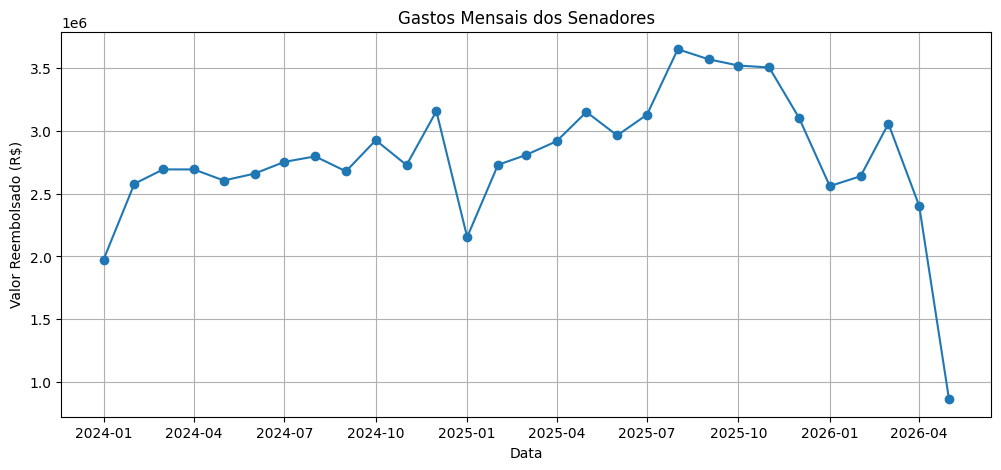

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    gastos_mensais['DATA'],
    gastos_mensais['VALOR_REEMBOLSADO'],
    marker='o',
)
plt.title('Gastos Mensais dos Senadores')
plt.xlabel('Data')
plt.ylabel('Valor Reembolsado (R$)')
plt.grid(True)
plt.show()

In [ ]:
# Criação da Baseline:

serie = gastos_mensais['VALOR_REEMBOLSADO']
train = serie[:-3]
test = serie[-3:]

In [ ]:
# Baseline média dos últimos 3 meses do treino:

baseline_value= train.tail(3).mean()
pred_baseline= [baseline_value] * len(test) 

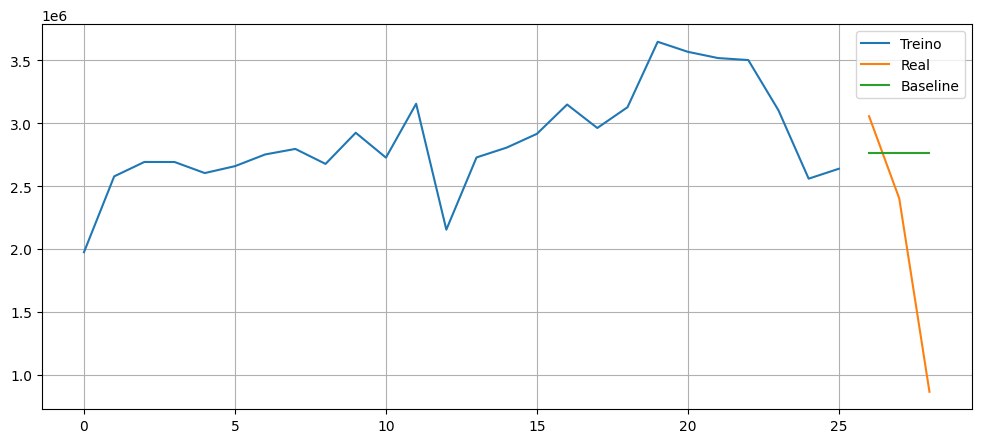

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Treino')
plt.plot(test.index, test, label='Real')
plt.plot(test.index, pred_baseline, label='Baseline')

plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, pred_baseline))
mape = mean_absolute_percentage_error(test, pred_baseline)

print("RMSE:", rmse)
print("MAPE:", mape)

RMSE: 1130246.1557128974
MAPE: 0.8146420971937363


In [ ]:
%pip install prophet

In [ ]:
df_prophet = gastos_mensais.rename(
    columns={
        'DATA': 'ds',
        'VALOR_REEMBOLSADO': 'y'
    }
)

In [ ]:
# Treinando o modelo Prophet:

from prophet import Prophet

model = Prophet()
model.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 22.


In [ ]:
future = model.make_future_dataframe(periods=3, freq='MS')
forecast = model.predict(future)

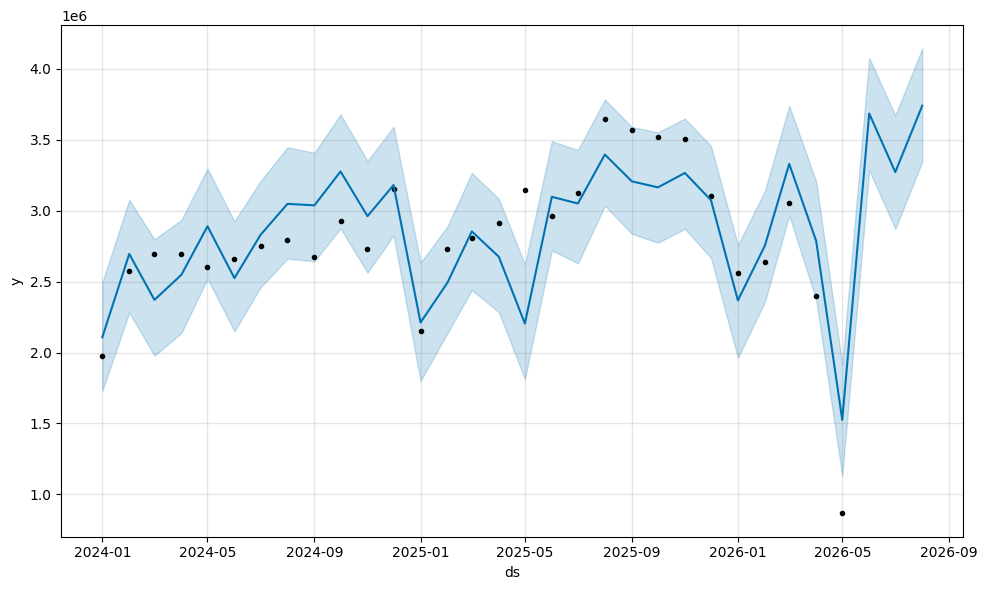

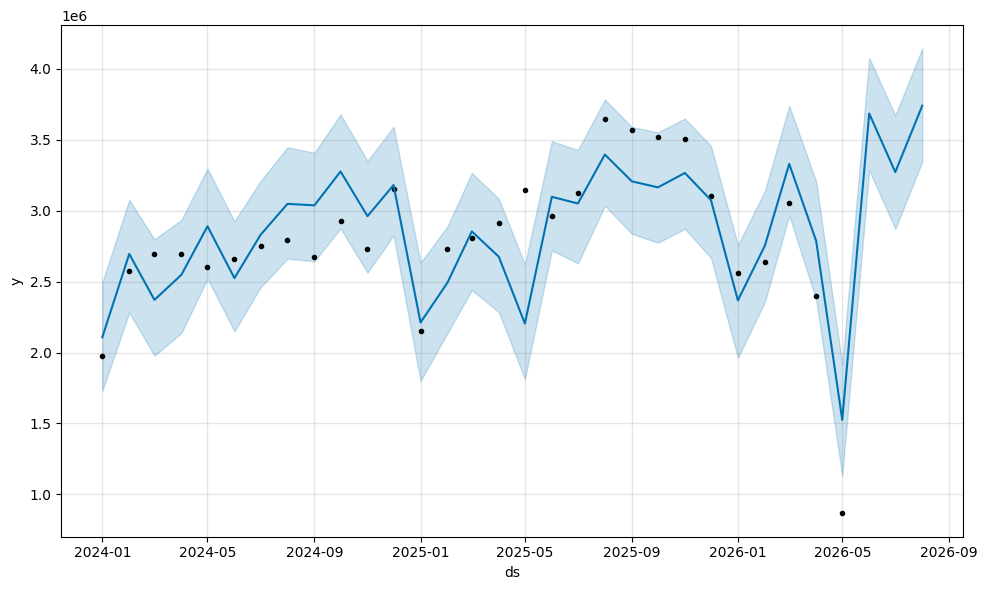

In [ ]:
model.plot(forecast)

In [ ]:
# Histórico vs Previsão:

df_result = forecast[['ds', 'yhat']].copy()

In [ ]:
# Juntando valores reais e previstos:

df_merge = df_result.merge(
    df_prophet,
    on='ds',
    how='left'
)

In [ ]:
# Separando treino e teste:

train = df_merge.dropna(subset=['y'])[:-3]
test = df_merge.dropna(subset=['y'])[-3:]

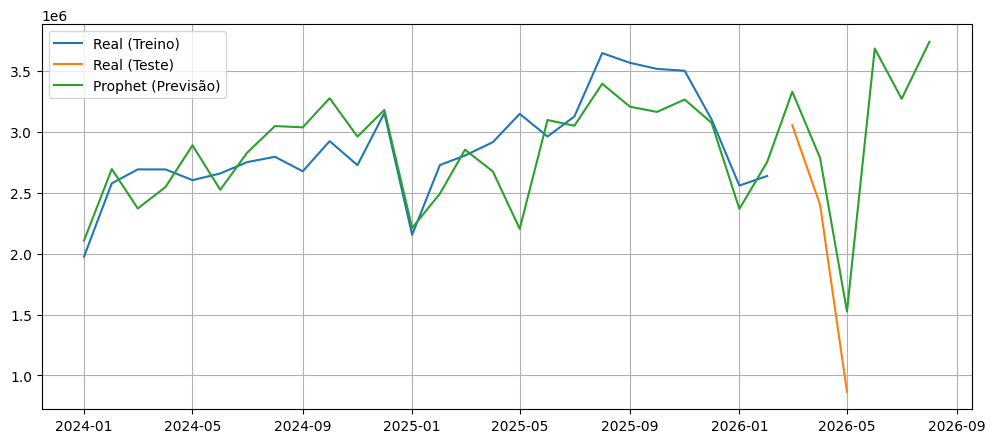

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train['ds'], train['y'], label='Real (Treino)')
plt.plot(test['ds'], test['y'], label='Real (Teste)')
plt.plot(df_merge['ds'], df_merge['yhat'], label='Prophet (Previsão)')

plt.legend()
plt.grid()
plt.show()

In [ ]:
# . Métricas (RMSE e MAPE):

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

y_true = test['y']
y_pred = test['yhat']

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAPE:", mape)

RMSE: 468529.1448662889
MAPE: 0.3374740399989897


In [ ]:
# PREVISÃO FINAL:

future_3m = model.make_future_dataframe(periods=3, freq='MS')
forecast_3m = model.predict(future_3m)

forecast_3m[['ds', 'yhat']].tail(3)

,ds,yhat
29,2026-06-01,3.685078e+06
30,2026-07-01,3.272033e+06
31,2026-08-01,3.740668e+06


In [ ]:
import numpy as np

df_prophet = df_prophet.copy()
df_prophet['y'] = np.log1p(df_prophet['y'])

In [ ]:
from prophet import Prophet

model = Prophet()
model.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 22.


In [ ]:
future = model.make_future_dataframe(periods=3, freq='MS')
forecast = model.predict(future)

forecast['yhat'] = np.expm1(forecast['yhat'])

In [ ]:
# Adicionar sazonalidade explícita:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

In [ ]:
# Adicionar sazonalidade customizada:
model.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)

In [ ]:
# Tratar Outliers:
q1 = df_prophet['y'].quantile(0.25)
q3 = df_prophet['y'].quantile(0.75)
iqr = q3 - q1

df_prophet = df_prophet[
    (df_prophet['y'] >= q1 - 1.5 * iqr) &
    (df_prophet['y'] <= q3 + 1.5 * iqr)
]

In [ ]:
from prophet import Prophet
import numpy as np

df_prophet = df_prophet.copy()

# log transform
df_prophet['y'] = np.log1p(df_prophet['y'])

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)

model.fit(df_prophet)

future = model.make_future_dataframe(periods=3, freq='MS')
forecast = model.predict(future)

forecast['yhat'] = np.expm1(forecast['yhat'])

INFO:prophet:n_changepoints greater than number of observations. Using 20.


In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    n_changepoints=8,
    changepoint_prior_scale=0.05
)

# 📌 Dia 4 — Sistema de Recomendação com Dados do CEAPS

Neste dia, o objetivo é aplicar conceitos de Sistemas de Recomendação utilizando os dados do CEAPS.

Embora o desafio original utilize o MovieLens como exemplo, a proposta será adaptada para o contexto dos gastos dos senadores, explorando padrões de comportamento semelhantes entre parlamentares.

## Objetivo

Construir um sistema capaz de identificar senadores com perfis de gastos semelhantes e, a partir dessas similaridades, gerar recomendações relacionadas aos tipos de despesas mais utilizados.

## Etapas do Projeto

### 1. Preparação dos Dados

* Selecionar as colunas relevantes para recomendação.
* Organizar os dados em formato adequado para análise de similaridade.

### 2. Construção da Matriz de Interações

* Criar uma matriz Senador × Tipo de Despesa.
* Utilizar os valores reembolsados como medida de interação.

### 3. Cálculo de Similaridade

* Aplicar a Similaridade do Cosseno (Cosine Similarity).
* Identificar senadores com padrões de gastos parecidos.

### 4. Sistema de Recomendação

* Encontrar os senadores mais semelhantes a um senador específico.
* Recomendar tipos de despesas frequentemente utilizados por senadores similares.

### 5. Avaliação dos Resultados

* Analisar se os agrupamentos encontrados fazem sentido.
* Interpretar os padrões de comportamento identificados.

### 6. Serialização do Modelo

* Salvar o modelo de recomendação utilizando Joblib.
* Permitir o carregamento e reutilização do modelo futuramente.

## Resultado Esperado

Ao final do projeto, será possível consultar um senador e identificar outros parlamentares com perfil de gastos semelhante, criando uma base para recomendações e análises comparativas de comportamento financeiro.


In [14]:
# Verificando quantidade de senadores e tipos de despesas únicos:
df = pd.read_csv(r'C:\Users\Jenifer\Desktop\ceaps\ceaps_limpo.csv')
print("Quantidade de senadores:", df['NOME_SENADOR'].nunique())
print("Quantidade de tipos de despesas:", df['TIPO_DESPESA'].nunique())

Quantidade de senadores: 97
Quantidade de tipos de despesas: 8


In [15]:
df['TIPO_DESPESA'].value_counts() 

TIPO_DESPESA
Locomoção, hospedagem, alimentação, combustíveis e lubrificantes                                                                                                                                   23320
Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.                                                                                                            9004
Passagens aéreas, aquáticas e terrestres nacionais                                                                                                                                                  6794
Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar                                                              5399
Divulgação da atividade parlamentar                                                                                                                                                    

In [16]:
# Criando a matriz de interações entre senadores e tipos de despesas:

matriz_interacoes = pd.pivot_table(
    df,
    index='NOME_SENADOR',
    columns= 'TIPO_DESPESA', 
    values='VALOR_REEMBOLSADO', 
    aggfunc='sum',
    fill_value=0
)

matriz_interacoes.head()

TIPO_DESPESA,"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.","Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.","Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",Divulgação da atividade parlamentar,"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes",NÃO INFORMADO,"Passagens aéreas, aquáticas e terrestres nacionais",Serviços de Segurança Privada
NOME_SENADOR,,,,,,,,
ALAN RICK,139076.27,2996.00,190658.52,398228.40,329619.29,0.00,1621.82,0.0
ALESSANDRO VIEIRA,229439.20,96929.53,512973.40,2750.00,400063.51,0.00,59747.08,0.0
ANA PAULA LOBATO,0.00,0.00,626795.38,210302.00,15919.16,31500.00,221809.82,0.0
ANDRÉ AMARAL,0.00,0.00,115129.95,0.00,0.00,1283.01,0.00,0.0
ANGELO CORONEL,7939.84,676.70,374628.00,105446.32,554372.91,94500.00,39000.39,0.0


In [17]:
matriz_interacoes.shape

(97, 8)

In [18]:
matriz_interacoes.head(20)

TIPO_DESPESA,"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.","Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.","Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",Divulgação da atividade parlamentar,"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes",NÃO INFORMADO,"Passagens aéreas, aquáticas e terrestres nacionais",Serviços de Segurança Privada
NOME_SENADOR,,,,,,,,
ALAN RICK,139076.27,2996.00,190658.52,398228.40,329619.29,0.00,1621.82,0.00
ALESSANDRO VIEIRA,229439.20,96929.53,512973.40,2750.00,400063.51,0.00,59747.08,0.00
ANA PAULA LOBATO,0.00,0.00,626795.38,210302.00,15919.16,31500.00,221809.82,0.00
ANDRÉ AMARAL,0.00,0.00,115129.95,0.00,0.00,1283.01,0.00,0.00
ANGELO CORONEL,7939.84,676.70,374628.00,105446.32,554372.91,94500.00,39000.39,0.00
ASTRONAUTA MARCOS PONTES,104593.83,38630.45,99175.17,383103.59,62218.59,98000.00,209615.27,0.00
AUGUSTA BRITO,274650.62,38698.64,37336.03,97591.70,291914.33,0.00,247334.56,0.00
BENE CAMACHO,35206.14,0.00,20000.00,0.00,61381.15,0.00,0.00,0.00
BETO FARO,0.00,0.00,424300.46,540563.01,193915.56,0.00,197953.44,0.00


In [19]:
# Calculando a similaridade entre os senadores usando a matriz de interações:

from sklearn.metrics.pairwise import cosine_similarity

similaridade = cosine_similarity(matriz_interacoes)

similaridade_df= pd.DataFrame(
    similaridade, 
    index=matriz_interacoes.index, 
    columns=matriz_interacoes.index
)

similaridade_df.head(10)

NOME_SENADOR,ALAN RICK,ALESSANDRO VIEIRA,ANA PAULA LOBATO,ANDRÉ AMARAL,ANGELO CORONEL,ASTRONAUTA MARCOS PONTES,AUGUSTA BRITO,BENE CAMACHO,BETO FARO,BETO MARTINS,...,SÉRGIO PETECÃO,TERESA LEITÃO,TEREZA CRISTINA,VANDERLAN CARDOSO,VENEZIANO VITAL DO RÊGO,WELLINGTON FAGUNDES,WEVERTON ROCHA,WILDER MORAIS,ZENAIDE MAIA,ZEQUINHA MARINHO
NOME_SENADOR,,,,,,,,,,,,,,,,,,,,,
ALAN RICK,1.000000,0.662111,0.526364,0.335482,0.763718,0.765396,0.657797,0.692602,0.855916,0.679569,...,0.878952,0.705593,0.646783,0.480782,0.736175,0.600920,0.699544,0.281853,0.794740,0.793848
ALESSANDRO VIEIRA,0.662111,1.000000,0.700012,0.733667,0.873699,0.351923,0.643517,0.834333,0.595601,0.955913,...,0.558983,0.774539,0.946326,0.564100,0.274423,0.495317,0.946827,0.425876,0.132554,0.701585
ANA PAULA LOBATO,0.526364,0.700012,1.000000,0.898121,0.580013,0.581759,0.306075,0.263186,0.824599,0.520433,...,0.749136,0.188297,0.801677,0.013034,0.601572,0.327495,0.634967,0.009366,0.341979,0.419930
ANDRÉ AMARAL,0.335482,0.733667,0.898121,1.000000,0.548356,0.210691,0.077139,0.271969,0.572597,0.559003,...,0.561422,0.149396,0.857511,0.002957,0.214809,0.013199,0.574184,0.002187,0.031590,0.188574
ANGELO CORONEL,0.763718,0.873699,0.580013,0.548356,1.000000,0.399804,0.597064,0.829784,0.652429,0.840288,...,0.564427,0.817142,0.887536,0.377302,0.376720,0.433968,0.811636,0.160789,0.264903,0.664432
ASTRONAUTA MARCOS PONTES,0.765396,0.351923,0.581759,0.210691,0.399804,1.000000,0.613605,0.271059,0.858565,0.345172,...,0.815157,0.318362,0.318174,0.262209,0.949881,0.740481,0.483830,0.238004,0.859330,0.709427
AUGUSTA BRITO,0.657797,0.643517,0.306075,0.077139,0.597064,0.613605,1.000000,0.796158,0.485660,0.723237,...,0.391051,0.820798,0.430364,0.783491,0.507954,0.936442,0.835750,0.548880,0.355879,0.975319
BENE CAMACHO,0.692602,0.834333,0.263186,0.271969,0.829784,0.271059,0.796158,1.000000,0.374206,0.923608,...,0.362089,0.969959,0.691737,0.802709,0.164124,0.573168,0.880550,0.473138,0.156966,0.814974
BETO FARO,0.855916,0.595601,0.824599,0.572597,0.652429,0.858565,0.485660,0.374206,1.000000,0.485275,...,0.946930,0.375846,0.672154,0.120034,0.897947,0.535020,0.601129,0.057341,0.778806,0.630595


In [20]:
# Primeira versão da função de recomendação:
def recomendar_senadores(nome_senador, top_n=5):
    
    similares = similaridade_df[nome_senador] \
        .sort_values(ascending=False) \
        .iloc[1:top_n+1]

    return similares

In [21]:
recomendar_senadores("DAVI ALCOLUMBRE")

NOME_SENADOR
ZENAIDE MAIA          0.976437
EFRAIM FILHO          0.963961
STYVENSON VALENTIM    0.952600
NELSINHO TRAD         0.926200
SÉRGIO PETECÃO        0.898687
Name: DAVI ALCOLUMBRE, dtype: float64

In [22]:
# Versão final da função de recomendação:

def recomendar_senadores(nome_senador, top_n=5):
    
    similares = similaridade_df[nome_senador] \
        .sort_values(ascending=False) \
        .iloc[1:top_n+1]

    print(f"Esses senadores têm o mesmo padrão de despesas do senador {nome_senador}:\n")
    
    for senador, score in similares.items():
        print(f"- {senador} (similaridade: {score:.2f})")
    
    print("\nEsses são os tipos de despesa mais característicos do grupo similar:\n")
    
    senadores_similares = similares.index
    
    despesas_media = matriz_interacoes.loc[senadores_similares].mean().sort_values(ascending=False)
    
    for despesa, valor in despesas_media.items():
        print(f"- {despesa}: {valor:.2f}")
    
    return similares

In [23]:
recomendar_senadores("DAVI ALCOLUMBRE")

Esses senadores têm o mesmo padrão de despesas do senador DAVI ALCOLUMBRE:

- ZENAIDE MAIA (similaridade: 0.98)
- EFRAIM FILHO (similaridade: 0.96)
- STYVENSON VALENTIM (similaridade: 0.95)
- NELSINHO TRAD (similaridade: 0.93)
- SÉRGIO PETECÃO (similaridade: 0.90)

Esses são os tipos de despesa mais característicos do grupo similar:

- Divulgação da atividade parlamentar: 735762.24
- Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar: 209720.08
- Locomoção, hospedagem, alimentação, combustíveis e lubrificantes: 119530.08
- Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.: 83994.01
- Passagens aéreas, aquáticas e terrestres nacionais: 23141.53
- Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos. : 772.49
- NÃO INFORMADO: 176.00

NOME_SENADOR
ZENAIDE MAIA          0.976437
EFRAIM FILHO          0.963961
STYVENSON VALENTIM    0.952600
NELSINHO TRAD         0.926200
SÉRGIO PETECÃO        0.898687
Name: DAVI ALCOLUMBRE, dtype: float64

In [24]:
import joblib

modelo_recomendacao = {
    "similaridade": similaridade_df,
    "matriz": matriz_interacoes,
    "top_n_default": 5
}

joblib.dump(modelo_recomendacao, "recomendador_ceaps.sav")

['recomendador_ceaps.sav']

# 📌 Dia 4 — Sistema de Recomendação com CEAPS

Neste dia, foi desenvolvido um sistema de recomendação utilizando os dados do CEAPS (Cota para Exercício da Atividade Parlamentar dos Senadores), aplicando conceitos fundamentais de Machine Learning e sistemas de recomendação baseados em similaridade.

---

## 🎯 Objetivo

Criar um sistema capaz de identificar senadores com padrões de gastos semelhantes e, a partir disso, gerar recomendações interpretáveis sobre comportamento de despesas parlamentares.

---

## 📊 Etapas realizadas

### 1. Construção da matriz de interação
Foi criada uma matriz no formato:

**Senador × Tipo de Despesa**

utilizando o valor total reembolsado como medida de interação entre senadores e categorias de gastos.

---

### 2. Cálculo de similaridade
Foi aplicada a **Similaridade do Cosseno (Cosine Similarity)** para medir o quanto os senadores possuem padrões de gastos semelhantes.

Isso permitiu identificar grupos de parlamentares com comportamentos financeiros parecidos.

---

### 3. Sistema de recomendação
Foi desenvolvida uma função de recomendação que:

- identifica os senadores mais semelhantes a um senador específico
- gera ranking de similaridade entre parlamentares
- analisa padrões de despesas mais comuns entre grupos similares

---

### 4. Interpretação dos resultados
O sistema permite responder perguntas como:

> “Quais senadores possuem padrão de gastos semelhante ao Senador X?”
> “Quais tipos de despesa caracterizam esse grupo de senadores?”

---

### 5. Serialização do modelo
O sistema foi salvo utilizando **Joblib**, permitindo armazenar toda a estrutura do recomendador em um único arquivo:

- matriz de interações
- matriz de similaridade

Isso facilita reutilização futura do modelo.

---

## 📌 Resultado final

Foi construído um sistema de recomendação baseado em similaridade entre usuários (senadores), capaz de identificar padrões de comportamento e gerar recomendações explicáveis sobre despesas parlamentares.

Este modelo aplica conceitos fundamentais de sistemas de recomendação utilizados em aplicações reais, adaptados ao contexto de dados públicos do CEAPS.

# 📌 Dia 5 — Disponibilizando o Modelo através de uma API

Neste dia, o objetivo foi transformar o sistema de recomendação desenvolvido anteriormente em um serviço acessível por meio de uma API REST.

A API permite que outras aplicações enviem requisições contendo o nome de um senador e recebam como resposta recomendações de parlamentares com perfis de gastos semelhantes.

Para isso, foi utilizada a biblioteca FastAPI, amplamente empregada em projetos de Machine Learning devido à sua simplicidade, velocidade e geração automática de documentação.

---

## 🎯 Objetivos

- Carregar o modelo salvo com Joblib
- Criar uma API utilizando FastAPI
- Disponibilizar um endpoint para recomendações
- Validar os dados recebidos na requisição
- Retornar resultados em formato JSON
- Testar a API utilizando Swagger, Postman ou Insomnia
- Simular um cenário real de deploy de modelos de Machine Learning

---

## 🚀 Resultado Esperado

Ao final desta etapa, o sistema de recomendação estará disponível através de uma API REST, permitindo seu consumo por aplicações externas.

In [57]:
%pip install fastapi uvicorn joblib

In [25]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib 
import pandas as pd
import numpy as np

In [26]:
# Função de recomendação ajustada para Api:

def recomendar_senadores(nome_senador, top_n=None):

    if top_n is None:
        top_n = modelo_recomendacao["top_n_default"]

    if nome_senador not in similaridade_df.columns:
        return None

    similares = (
        similaridade_df[nome_senador]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
    )

    senadores_similares = similares.index

    # Perfil do senador consultado
    perfil_senador = matriz_interacoes.loc[nome_senador]

    # Perfil médio dos senadores similares
    perfil_grupo = (
        matriz_interacoes
        .loc[senadores_similares]
        .mean()
    )

    # Comparação senador x grupo
    comparacao = pd.DataFrame({
        "valor_senador": perfil_senador,
        "valor_grupo": perfil_grupo
    })

    comparacao = (
        comparacao
        .sort_values("valor_grupo", ascending=False)
        .head(5)
    )

    return {
        "senador_consultado": nome_senador,

        "senadores_similares": [
            {
                "nome": senador,
                "similaridade": round(float(score), 2)
            }
            for senador, score in similares.items()
        ],

        "comparacao_despesas": [
            {
                "tipo_despesa": despesa,
                "valor_senador": round(float(linha["valor_senador"]), 2),
                "valor_grupo": round(float(linha["valor_grupo"]), 2)
            }
            for despesa, linha in comparacao.iterrows()
        ]
    }

In [27]:
recomendar_senadores("DAVI ALCOLUMBRE", top_n=3)

{'senador_consultado': 'DAVI ALCOLUMBRE',
 'senadores_similares': [{'nome': 'ZENAIDE MAIA', 'similaridade': 0.98},
  {'nome': 'EFRAIM FILHO', 'similaridade': 0.96},
  {'nome': 'STYVENSON VALENTIM', 'similaridade': 0.95}],
 'comparacao_despesas': [{'tipo_despesa': 'Divulgação da atividade parlamentar',
   'valor_senador': 1047699.89,
   'valor_grupo': 829575.03},
  {'tipo_despesa': 'Locomoção, hospedagem, alimentação, combustíveis e lubrificantes',
   'valor_senador': 46909.36,
   'valor_grupo': 160072.14},
  {'tipo_despesa': 'Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar',
   'valor_senador': 212000.0,
   'valor_grupo': 106900.04},
  {'tipo_despesa': 'Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.',
   'valor_senador': 0.0,
   'valor_grupo': 43774.91},
  {'tipo_despesa': 'Passagens aéreas, aquáticas e terrestres nacionais',
   'valor_senador': 0.0,
   'valo

In [28]:
# Criando a API:

app = FastAPI(
    title="API CEAPS",
    description="Sistema de recomendação de senadores com base em padrões de despesas do CEAPS",
    version="1.0"
) 

In [29]:
# Modelo de entrada:


class Requisicao(BaseModel):
    senador: str

In [30]:
# Endpoint de recomendação:

@app.post("/recomendar")
def recomendar(req: Requisicao):

    resultado = recomendar_senadores(req.senador)

    if resultado is None:

        raise HTTPException(
            status_code=404,
            detail="Senador não encontrado."
        )

    return resultado

In [31]:
# Endpoint de teste:
@app.get("/")
def home():

    return {
        "mensagem":
        "API de recomendação CEAPS funcionando!"
    }

Foi realizada a etapa de disponibilização do modelo de Machine Learning por meio de uma API REST utilizando FastAPI.

Foi criado o arquivo app.py, responsável por centralizar toda a lógica da API, incluindo o carregamento do modelo de recomendação previamente salvo com Joblib e a definição dos endpoints para consulta.

A aplicação foi configurada para receber requisições HTTP e retornar recomendações de senadores com perfis de gastos semelhantes.

Também foram implementadas validações para tratamento de erros, garantindo que apenas senadores existentes na base possam ser consultados. Além disso, a estrutura das respostas foi aprimorada para retornar dados em formato JSON organizado e de fácil interpretação.

A API foi testada utilizando a documentação automática gerada pelo FastAPI (Swagger UI), permitindo validar o funcionamento dos endpoints e simular o consumo do modelo por aplicações externas.

Como etapa complementar, foi preparada a estrutura necessária para futura containerização da aplicação com Docker, facilitando possíveis processos de deploy e integração em ambientes de produção.

Com isso, o projeto evoluiu de um modelo treinado localmente para um serviço capaz de disponibilizar previsões e recomendações através de uma interface padronizada, aproximando-se de cenários reais de utilização de Machine Learning em produção.

O projeto foi inicialmente desenvolvido no Google Colab, com utilização do Google Drive para armazenamento e acesso aos dados durante a etapa de exploração e treinamento do modelo.

No entanto, para fins de produção e portfólio, a aplicação foi adaptada para independência do ambiente Colab, passando a utilizar arquivos locais dentro da estrutura do projeto, garantindo portabilidade e compatibilidade com execução via API e Docker.